# Pipeline reproducible de preprocesado para EDA y PPG

Este notebook reproduce el pipeline descrito en el artículo con la nueva
organización de datos:

- `data/eda/<usuario>.csv`
- `data/ppg/<usuario>.csv`
- `data/stamps/<usuario>.txt`

En este caso reproducible, los `stamps` se usan para localizar el tramo
`squat` de cada sujeto y aplicar el pipeline sobre ese segmento.


In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def resolve_pipeline_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "pipeline", cwd.parent]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "preprocessing").exists():
            return candidate
    raise FileNotFoundError("No se ha podido localizar la carpeta pipeline desde el directorio de trabajo actual.")


PIPELINE_DIR = resolve_pipeline_dir()
DATA_DIR = PIPELINE_DIR / "data"

if str(PIPELINE_DIR) not in sys.path:
    sys.path.insert(0, str(PIPELINE_DIR))

from data_layout import list_subject_ids, load_subject_signal, load_subject_stamps, segment_signal
from metrics.eda_metrics import bottcher_quality, kleckner_quality, kleckner_quality_filter
from metrics.ppg_metrics import maki_quality
from preprocessing.filtering import butterworth_bvp, gaussian_gsr
from preprocessing.hr import hr_emotibit
from preprocessing.outliers import IQR
from preprocessing.resampling import resample_with_spline

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SUBJECT_IDS = list_subject_ids(DATA_DIR)

print(f"Directorio pipeline: {PIPELINE_DIR}")
print(f"Sujetos encontrados: {SUBJECT_IDS}")


Directorio pipeline: C:\Users\Usuario\Documents\GitHub\Caepia\pipeline
Sujetos encontrados: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']


## Funciones auxiliares


In [22]:
def estimate_sampling_rate(df, timestamp_col="Timestamp"):
    time_diffs = np.diff(df[timestamp_col].to_numpy(dtype=float))
    time_diffs = time_diffs[time_diffs > 0]
    if len(time_diffs) == 0:
        raise ValueError("No se ha podido estimar la frecuencia de muestreo a partir de los timestamps.")
    return 1.0 / np.median(time_diffs)


def preprocess_eda(subject_id, target_frequency=15):
    raw_full_df = load_subject_signal(DATA_DIR, "eda", subject_id, "EA")
    stamps = load_subject_stamps(DATA_DIR, subject_id)
    raw_df = segment_signal(raw_full_df, stamps, "squat")
    raw_frequency = estimate_sampling_rate(raw_df)
    resampled_df = resample_with_spline(raw_df, target_frequency=target_frequency, signal_col="EA")
    outlier_df = IQR(resampled_df.copy(), "EA")
    filtered_df = gaussian_gsr(outlier_df.copy(), "EA", sampling_rate=target_frequency)

    return {
        "subject": subject_id,
        "raw_frequency": raw_frequency,
        "target_frequency": target_frequency,
        "raw": raw_df,
        "resampled": resampled_df,
        "outlier_cleaned": outlier_df,
        "filtered": filtered_df,
    }


def compute_hr_safe(df, sampling_rate, signal_col="PG", output_col="Hr"):
    try:
        return hr_emotibit(df, sampling_rate=sampling_rate, signal_col=signal_col, output_col=output_col)
    except Exception:
        return pd.DataFrame(columns=["Timestamp", output_col])


def preprocess_ppg(subject_id, target_frequency=50):
    raw_full_df = load_subject_signal(DATA_DIR, "ppg", subject_id, "PG")
    stamps = load_subject_stamps(DATA_DIR, subject_id)
    raw_df = segment_signal(raw_full_df, stamps, "squat")
    raw_frequency = estimate_sampling_rate(raw_df)
    hr_raw_df = compute_hr_safe(raw_df, sampling_rate=raw_frequency, signal_col="PG", output_col="Hr")
    resampled_df = resample_with_spline(raw_df, target_frequency=target_frequency, signal_col="PG")
    outlier_df = IQR(resampled_df.copy(), "PG")
    filtered_df = butterworth_bvp(outlier_df.copy(), "PG", sampling_rate=target_frequency)
    hr_df = compute_hr_safe(filtered_df, sampling_rate=target_frequency, signal_col="PG", output_col="Hr")

    return {
        "subject": subject_id,
        "raw_frequency": raw_frequency,
        "target_frequency": target_frequency,
        "raw": raw_df,
        "hr_raw": hr_raw_df,
        "resampled": resampled_df,
        "outlier_cleaned": outlier_df,
        "filtered": filtered_df,
        "hr": hr_df,
    }


def summarize_eda(result):
    raw = result["raw"]["EA"].to_numpy()
    filtered = result["filtered"]["EA"].to_numpy()
    raw_fs = max(1, int(round(result["raw_frequency"])))
    target_fs = int(result["target_frequency"])
    duration_s = result["raw"]["Timestamp"].iloc[-1] - result["raw"]["Timestamp"].iloc[0]

    return {
        "subject": result["subject"],
        "target_fs": result["target_frequency"],
        "duration_s": duration_s,
        "bottcher_raw": bottcher_quality(raw, fs=raw_fs),
        "bottcher_filtered": bottcher_quality(filtered, fs=target_fs),
        "kleckner_raw": kleckner_quality(raw, fs=raw_fs),
        "kleckner_filtered": kleckner_quality(filtered, fs=target_fs),
        "kleckner_filtered_smoothed": kleckner_quality_filter(filtered),
    }


def summarize_ppg(result):
    raw = result["raw"]["PG"].to_numpy()
    filtered = result["filtered"]["PG"].to_numpy()
    hr_raw = result["hr_raw"]
    hr = result["hr"]
    raw_fs = max(1, int(round(result["raw_frequency"])))
    target_fs = int(result["target_frequency"])
    duration_s = result["raw"]["Timestamp"].iloc[-1] - result["raw"]["Timestamp"].iloc[0]

    return {
        "subject": result["subject"],
        "target_fs": result["target_frequency"],
        "duration_s": duration_s,
        "maki_raw": maki_quality(raw, fs=raw_fs),
        "maki_filtered": maki_quality(filtered, fs=target_fs),
        "hr_samples_raw": len(hr_raw),
        "hr_mean_raw": hr_raw["Hr"].mean() if not hr_raw.empty else np.nan,
        "hr_std_raw": hr_raw["Hr"].std() if not hr_raw.empty else np.nan,
        "hr_samples_final": len(hr),
        "hr_mean_final": hr["Hr"].mean() if not hr.empty else np.nan,
        "hr_std_final": hr["Hr"].std() if not hr.empty else np.nan,
        "hr_min_final": hr["Hr"].min() if not hr.empty else np.nan,
        "hr_max_final": hr["Hr"].max() if not hr.empty else np.nan,
    }


## Ejemplo visual de un sujeto


In [23]:
example_subject = SUBJECT_IDS[0]
example_eda = preprocess_eda(example_subject, target_frequency=15)
example_ppg = preprocess_ppg(example_subject, target_frequency=50)


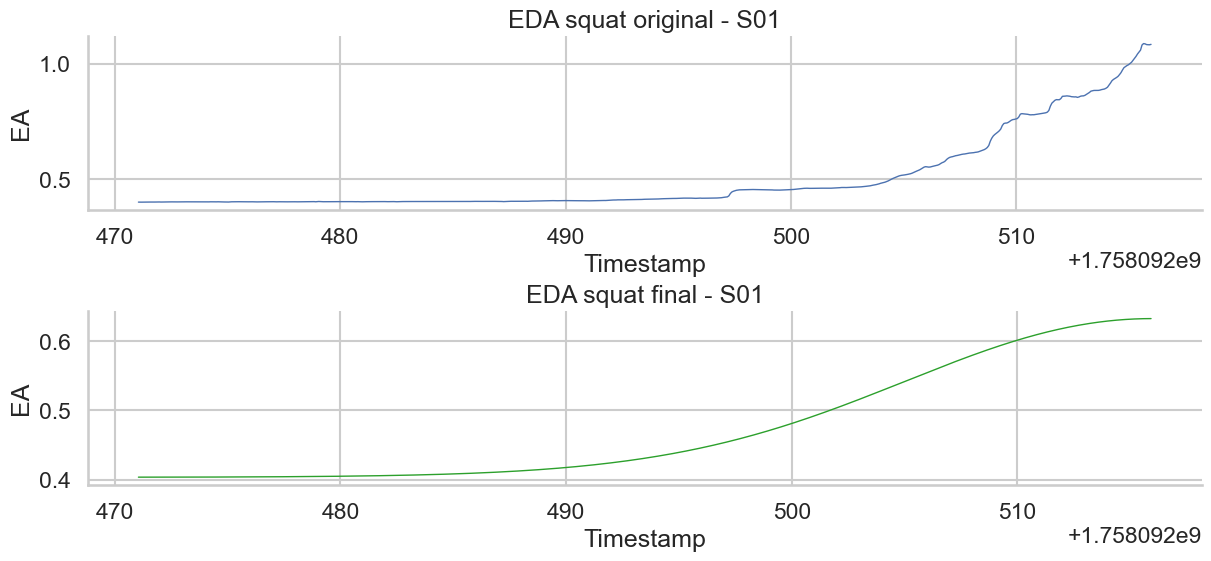

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), constrained_layout=True)

axes[0].plot(example_eda["raw"]["Timestamp"], example_eda["raw"]["EA"], linewidth=1)
axes[0].set_title(f"EDA squat original - {example_eda['subject']}")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("EA")

axes[1].plot(example_eda["filtered"]["Timestamp"], example_eda["filtered"]["EA"], linewidth=1, color="tab:green")
axes[1].set_title(f"EDA squat final - {example_eda['subject']}")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("EA")

plt.show()


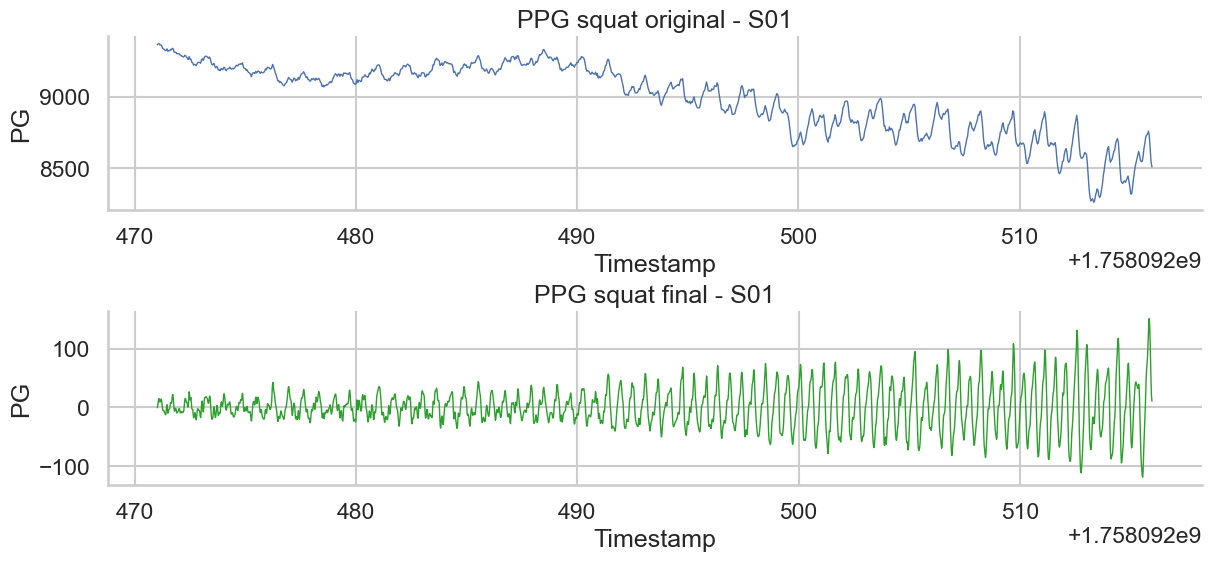

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), constrained_layout=True)

axes[0].plot(example_ppg["raw"]["Timestamp"], example_ppg["raw"]["PG"], linewidth=1)
axes[0].set_title(f"PPG squat original - {example_ppg['subject']}")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("PG")

axes[1].plot(example_ppg["filtered"]["Timestamp"], example_ppg["filtered"]["PG"], linewidth=1, color="tab:green")
axes[1].set_title(f"PPG squat final - {example_ppg['subject']}")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("PG")

plt.show()


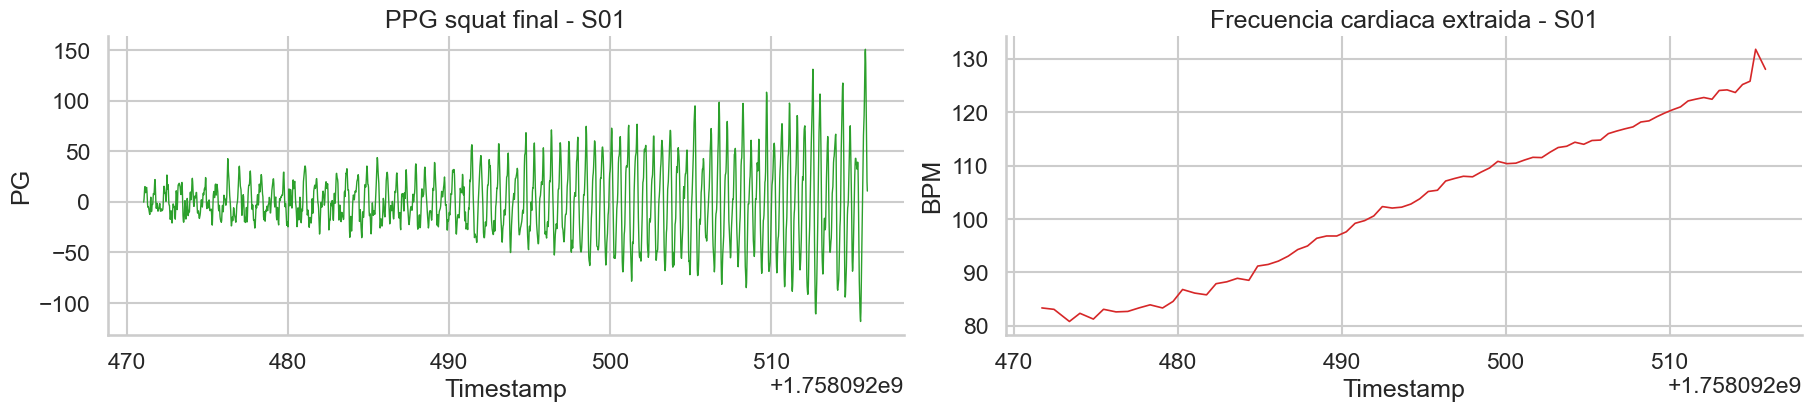

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4), constrained_layout=True)

axes[0].plot(example_ppg["filtered"]["Timestamp"], example_ppg["filtered"]["PG"], linewidth=1, color="tab:green")
axes[0].set_title(f"PPG squat final - {example_ppg['subject']}")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("PG")

axes[1].plot(example_ppg["hr"]["Timestamp"], example_ppg["hr"]["Hr"], linewidth=1.2, color="tab:red")
axes[1].set_title(f"Frecuencia cardiaca extraida - {example_ppg['subject']}")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("BPM")

plt.show()


## Ejecución completa sobre todos los sujetos


In [27]:
eda_results = [preprocess_eda(subject_id, target_frequency=15) for subject_id in SUBJECT_IDS]
ppg_results = [preprocess_ppg(subject_id, target_frequency=50) for subject_id in SUBJECT_IDS]

eda_summary = pd.DataFrame([summarize_eda(result) for result in eda_results]).sort_values("subject")
ppg_summary = pd.DataFrame([summarize_ppg(result) for result in ppg_results]).sort_values("subject")

eda_summary


,subject,target_fs,duration_s,bottcher_raw,bottcher_filtered,kleckner_raw,kleckner_filtered,kleckner_filtered_smoothed
0,S01,15,44.928557,1.000000,1.000000,1.000000,1.0,1.0
1,S02,15,44.928895,0.866667,1.000000,1.000000,1.0,1.0
2,S03,15,43.928948,0.863636,1.000000,1.000000,1.0,1.0
3,S04,15,44.928959,0.777778,0.777448,1.000000,1.0,1.0
4,S05,15,43.929411,0.772727,0.863429,1.000000,1.0,1.0
5,S06,15,44.928377,0.733333,0.688427,1.000000,1.0,1.0
6,S07,15,43.928639,0.954545,1.000000,1.000000,1.0,1.0
7,S08,15,44.928304,0.911111,1.000000,1.000000,1.0,1.0
8,S09,15,43.929030,0.000000,0.000000,0.036364,0.0,0.0
9,S10,15,43.931196,0.818182,1.000000,1.000000,1.0,1.0


In [28]:
ppg_summary


,subject,target_fs,duration_s,maki_raw,maki_filtered,hr_samples_raw,hr_mean_raw,hr_std_raw,hr_samples_final,hr_mean_final,hr_std_final,hr_min_final,hr_max_final
0,S01,50,44.956057,0.194235,0.482835,0,NaN,NaN,79,104.331856,14.471087,80.795629,131.788246
1,S02,50,44.928895,0.399691,0.153058,0,NaN,NaN,96,130.502143,17.411436,92.801074,152.239149
2,S03,50,43.968948,0.430312,0.456029,5,7.432801,1.891022,63,99.303682,14.703961,81.947320,150.000000
3,S04,50,44.968959,0.762869,0.263235,0,NaN,NaN,79,105.009819,15.869404,74.883921,126.839793
4,S05,50,43.955911,0.257641,0.349785,2,3.479191,1.711057,80,115.658679,11.376139,101.471973,153.125875
5,S06,50,44.968877,0.385912,0.126492,0,NaN,NaN,94,128.128186,11.252276,109.115350,143.483236
6,S07,50,43.955139,0.392961,0.284735,0,NaN,NaN,76,119.408368,11.393565,100.540541,166.666667
7,S08,50,44.981804,0.436411,0.134376,0,NaN,NaN,75,100.772951,6.717709,91.140037,110.886892
8,S09,50,43.955030,0.485180,0.223192,0,NaN,NaN,84,114.231826,11.127410,91.417076,127.032996
9,S10,50,43.957697,0.248314,0.172906,0,NaN,NaN,91,126.768556,6.844559,114.360994,137.602039


## Resultados agregados

Nota de interpretación para la métrica de calidad PPG:
- Maki quality es mejor cuanto menor es su valor.
- Valores más bajos indican amplitudes de pico más estables.
- Valores más altos indican mayor variabilidad y, por tanto, peor calidad de señal.

Nota de interpretación para el resumen agregado:
- En EDA, diferencias positivas significan que la señal filtrada mejoró respecto a la original.
- En PPG, reducciones positivas significan que la señal filtrada mejoró porque Maki quality disminuyó.


In [29]:
aggregate_results = pd.DataFrame(
    {
        "metric": [
            "Cambio medio EDA Böttcher (final - original)",
            "Cambio medio EDA Kleckner (final - original)",
            "Reducción media PPG Maki quality (original - final)",
            "Reducción relativa PPG Maki quality (%)",
        ],
        "value": [
            (eda_summary["bottcher_filtered"] - eda_summary["bottcher_raw"]).mean(),
            (eda_summary["kleckner_filtered"] - eda_summary["kleckner_raw"]).mean(),
            (ppg_summary["maki_raw"] - ppg_summary["maki_filtered"]).mean(),
            (
                (ppg_summary["maki_raw"] - ppg_summary["maki_filtered"])
                / ppg_summary["maki_raw"]
                * 100
            ).mean(),
        ],
    }
)

aggregate_results


,metric,value
0,Cambio medio EDA Böttcher (final - original),0.063133
1,Cambio medio EDA Kleckner (final - original),-0.003636
2,Reducción media PPG Maki quality (original - f...,0.134688
3,Reducción relativa PPG Maki quality (%),18.521489


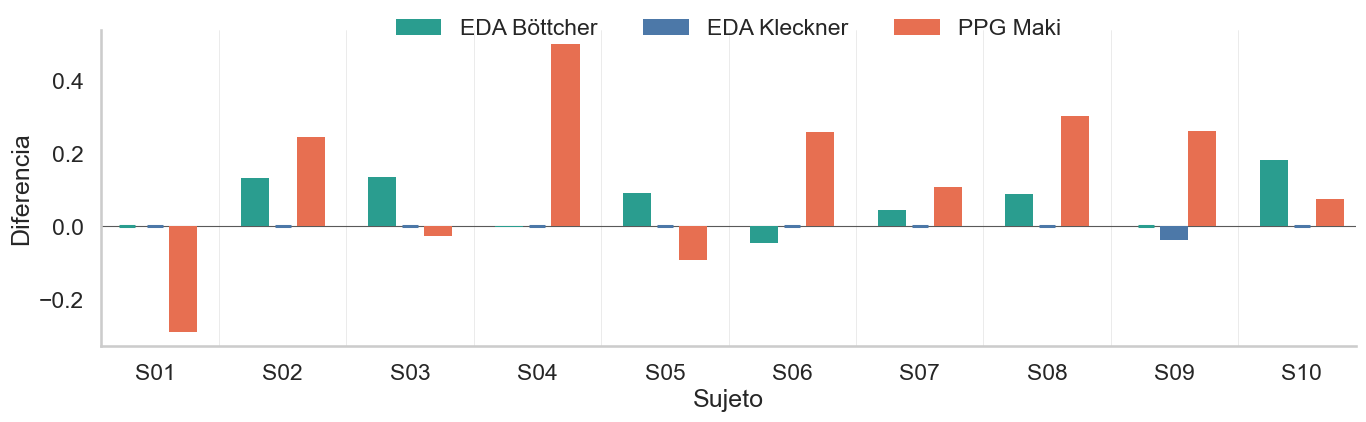

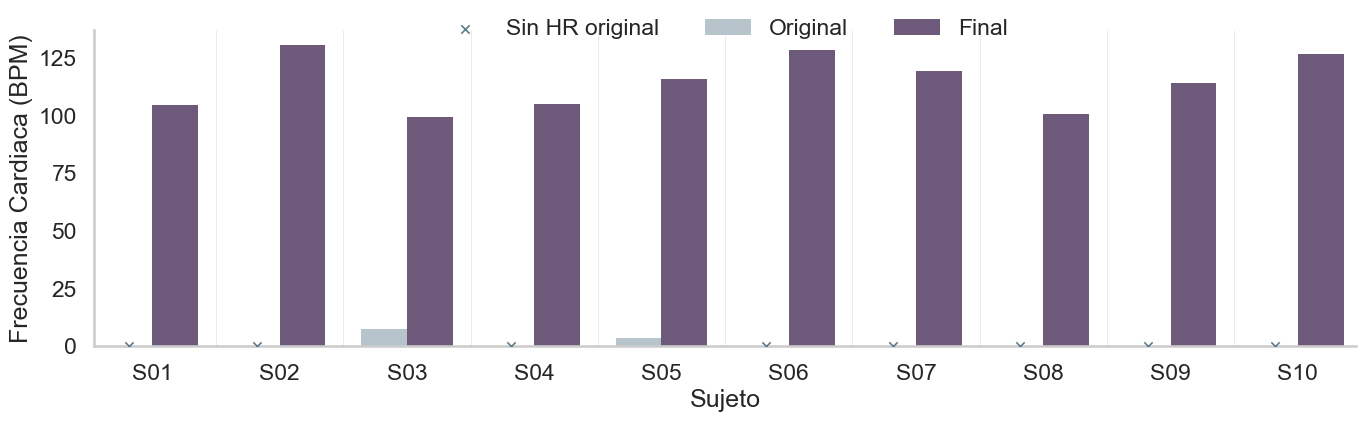

In [30]:
plot_df = (
    eda_summary[["subject", "bottcher_raw", "bottcher_filtered", "kleckner_raw", "kleckner_filtered"]]
    .merge(
        ppg_summary[["subject", "maki_raw", "maki_filtered", "hr_mean_raw", "hr_mean_final"]],
        on="subject",
        how="outer",
    )
    .sort_values("subject")
    .reset_index(drop=True)
)

plot_df["EDA Böttcher"] = plot_df["bottcher_filtered"] - plot_df["bottcher_raw"]
plot_df["EDA Kleckner"] = plot_df["kleckner_filtered"] - plot_df["kleckner_raw"]
plot_df["PPG Maki"] = plot_df["maki_raw"] - plot_df["maki_filtered"]

subjects = plot_df["subject"].astype(str).tolist()
x = np.arange(len(subjects))

fig_width = max(14, len(subjects) * 0.6)

boundaries = x[:-1] + 0.5
separator_color = "0.88"
separator_lw = 0.45


# ============================================================
# PLOT 1: METRICAS DE CALIDAD
# ============================================================
fig, ax = plt.subplots(figsize=(fig_width, 4.6))

quality_width = 0.22
quality_specs = [
    ("EDA Böttcher", -quality_width, "#2a9d8f"),
    ("EDA Kleckner", 0.0, "#4c78a8"),
    ("PPG Maki", quality_width, "#e76f51"),
]

for boundary in boundaries:
    ax.axvline(
        boundary,
        color=separator_color,
        linewidth=separator_lw,
        zorder=0
    )

for metric_name, offset, color in quality_specs:
    ax.bar(
        x + offset,
        plot_df[metric_name],
        width=quality_width,
        color=color,
        label=metric_name,
        edgecolor="none",
        linewidth=0,
        zorder=2
    )

zero_marker_lw = 2.2

for metric_name, offset, color in quality_specs:
    zero_mask = plot_df[metric_name].eq(0)

    if zero_mask.any():
        ax.scatter(
            x[zero_mask] + offset,
            np.zeros(zero_mask.sum()),
            marker="_",
            s=120,
            linewidths=zero_marker_lw,
            color=color,
            zorder=4
        )

ax.axhline(
    0,
    color="0.35",
    linewidth=0.8,
    zorder=1
)

ax.set_ylabel("Diferencia")
ax.set_xlabel("Sujeto")
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=0, ha="center")

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10)
)

ax.margins(x=0.01)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    "metrics_before_after.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 2: FRECUENCIA CARDIACA
# ============================================================
fig, ax = plt.subplots(figsize=(fig_width, 4.6))

hr_width = 0.36
raw_hr = plot_df["hr_mean_raw"].to_numpy(dtype=float)
final_hr = plot_df["hr_mean_final"].to_numpy(dtype=float)

for boundary in boundaries:
    ax.axvline(
        boundary,
        color=separator_color,
        linewidth=separator_lw,
        zorder=0
    )

ax.bar(
    x - hr_width / 2,
    np.nan_to_num(raw_hr, nan=0.0),
    width=hr_width,
    color="#b8c4cc",
    label="Original",
    edgecolor="none",
    linewidth=0,
    zorder=2
)

ax.bar(
    x + hr_width / 2,
    np.nan_to_num(final_hr, nan=0.0),
    width=hr_width,
    color="#6d597a",
    label="Final",
    edgecolor="none",
    linewidth=0,
    zorder=2
)

raw_missing = np.isnan(raw_hr)
final_missing = np.isnan(final_hr)

if raw_missing.any():
    ax.scatter(
        x[raw_missing] - hr_width / 2,
        np.zeros(raw_missing.sum()),
        marker="x",
        s=36,
        linewidths=1.2,
        color="#607d8b",
        label="Sin HR original",
        zorder=3
    )

if final_missing.any():
    ax.scatter(
        x[final_missing] + hr_width / 2,
        np.zeros(final_missing.sum()),
        marker="x",
        s=36,
        linewidths=1.2,
        color="#4e3d59",
        label="Sin HR final",
        zorder=3
    )

ax.set_ylabel("Frecuencia Cardiaca (BPM)")
ax.set_xlabel("Sujeto")
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=0, ha="center")

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10)
)

ax.margins(x=0.01)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    "hr_before_after.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
